In [1]:
# 1 Importar as bibs necessárias e setar o device
from abc import ABC, abstractmethod
from typing import Optional
import math
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# 2 Definido método abstrato para o EDO 
class EDO(ABC):
    # Parte determinística da função, para EDO o coeficiente de difusão é igual a zero
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o coeficiente drift da EDO:
        Args:
        - xt: estado no tempo t, shape = (bs, dim)
        - t: tempo, shape = ()
        Retorna:
        -drift_coefficient: shape (bs, dim)
        """
        pass

# 3 Definido método abstrato para o EDE
class EDE(ABC):
    # Assim como a EDO, também possui uma parte determinística
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o coeficiente drift da EDO na EDE
        Args:
        - xt: estado no tempo t, shape = (bs, dim)
        - t: tempo, shape = ()
        Retorna:
        -drift_coefficient: shape = (bs, dim)  
        """
        pass
    # Coeficiente de difusão da EDE
    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o coeficiente de difusão da EDE
        Args:
        -xt: estado no tempo t, shape = (bs, dim)
        -t: tempo, shape = ()
        Retorna:
        -diffusion_coefficient: shape = (bs, dim)
        """
        pass
        

In [3]:
# 4 Métodos numéricos para simular EDOs e EDEs 
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor) -> torch.Tensor:
        """
        Corresponde a um passo (h) na simulação
        Args:
        -xt: estado no tempo t, shape=(bs, dim)
        -t: tempo t, shape=()
        -dt: tempo infinitesimal dt, shape=()
        Retorna:
        -nxt: próxima estado xt no tempo = t + dt, shape=(bs, dim)
        """
        pass

    # torch.no_grad para não computar gradientes (maior velocidade, a computação é necessária apenas durante treinamento)
    @torch.no_grad()        
    def simulate(self, x: torch.Tensor, ts: torch.Tensor):
        """
        Simulação usando discretização dado por ts
        Args:
        -x_init: estado x inicial no tempo ts[0], shape=(bs, dim)
        -ts: estados de tempo t, shape= (nts,),  nts = num_timesteps
        Retorna:
        x_final: estado x final no tempo ts[-1], shape=(bs,dim)
        
        """
        for t_idx in range(len(ts)-1):
            t = ts[t_idx]
            h = ts[t_idx + 1] - ts[t_idx] # h = dt
            x = self.step(x, t, h)        
        return x

    # simulação com trajetória
    @torch.no_grad()
    def simulate_with_trajectory(self, x:torch.Tensor, ts: torch.Tensor):
        """
        Simula usando a discretização de ts
        Args:
        -x_inicial: estado x inicial no tempo, ts[0], shape=(bs,dim)
        -ts: estados de tempo t, shape=(nts,)
        Retorna:
        xs: trajetória dos estados xts nos ts, shape=(bs, nts, dim)
        """
        xs = [x.clone()]
        for t_idx in tqdm(range(len(ts)-1)):
            t = ts[t_idx]
            h = ts[t_idx+1] - ts[t_idx]
            x = self.step(x, t, h)
            xs.append(x)
        return torch.stack(xs, dim=1)
            

In [4]:
# 5 Implementação do método de Euler
class EulerSimulator(Simulator):
    def __init__(self, edo: EDO):
        self.edo = edo

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        """
        Corresponde a um passo na simulação de Euler
        Args:
        -xt: estado no tempo t, shape=(bs, dim)
        -t: tempo t, shape=()
        -h: passo de tempo infinitesimal dt, shape=()
        Retorna:
        -nxt: próxima estado xt no tempo = t + h, shape=(bs, dim)
        Método de Euler:
        x_{t+h} = xt + h * u(xt)
        """
        drift_coefficient = self.edo.drift_coefficient(xt, t) # shape = (bs, dim)
        nxt = xt + h * drift_coefficient  # Euler step
        return nxt

# 6 Implementação do método de Euler-Maruyama
class EulerMaruyamaSimulator(Simulator):
    def __init__(self, ede: EDE):
        self.ede = ede

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        """
        Corresponde a um passo na simulação de EM
        Args:
        - xt: estado no tempo t, shape=(bs, dim)
        - t: tempo t, shape=()
        - h: passo de tempo infinitesimal dt, shape=()
        Retorna:
        -nxt: próximo estado xt no tempo = t + h, adicionado ao ruido estocástico.
        Método de Euler-Maruyama:
        x_{t+h} = xt + h * u(xt) + diffusion_coefficient*sqrt(h)epsilon, epsilon ~ N(0, I) -> shape=(bs, dim) = xt shape
        """
        drift_coefficient = self.ede.drift_coefficient(xt, t)
        diffusion_coefficient = self.ede.diffusion_coefficient(xt, t)
        nxt = xt + h * drift_coefficient + diffusion_coefficient * torch.sqrt(h) * torch.randn_like(xt)
        return nxt
        
        
   

    

In [5]:
# 6 Definir a classe para o movimento Browniano em X_{0} = 0
class BrownianMotion(EDE):
    """
    Movimento Browniano é definido como:
    dXt = sigma*dWt, X0 = 0.
    coeficiente de drift (h*u_{t}(xt)) é zero para o movimento browniano, pois u_{t}(xt) = 0
    """
    def __init__(self, sigma: float):
        self.sigma = sigma

    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Coeficiente drift para uma EDO
        Args:
        -xt: estado x no tempo t, shape = (bs, dim)
        -t: tempo t, shape=()
        Retorna:
        drift_coefficient, shape=(bs, dim)
        """
        return torch.zeros_like(xt)

    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Coeficiente de difusão para uma EDO
        Args:
        -xt: estado x no tempo t, shape=(bs,dim)
        -t: tempo t, shape=()
        Retorna:
        coeficiente de difusão, shape=(bs,dim)
        """
        return self.sigma * torch.ones_like(xt)

In [6]:
# 7 Simulando o movimento Browniano em 1D
def plot_trajectories_1d(x0: torch.Tensor, simulator: Simulator, timesteps: torch.Tensor, ax: Optional[Axes] = None):
    """
    Plota as trajetórias para uma EDE unidimensional, dado valores iniciais de x0 e dos timesteps
    Args:
    -x0: estado x no tempo t, shape=(num_trajectories, 1)
    - simulator: Objeto Simulator usado para a simulação
    - t: timesteps durante a simulação, shape=(num_timesteps,)
    -ax: Objeto pyplot Axes para plotar 
    """
    if ax is None:
        ax = plt.gca()
    trajectories = simulator.simulate_with_trajectory(x0, timesteps) # (num_trajectories, num_timesteps,...)
    for trajectory_idx in range(trajectories.shape[0]):
        trajectory = trajectories[trajectory_idx, :, 0] # (num_timesteps,)
        ax.plot(timesteps.cpu(), trajectory.cpu())

100%|█████████████████████████████████████████████████████████████████████████████| 499/499 [00:00<00:00, 17464.89it/s]


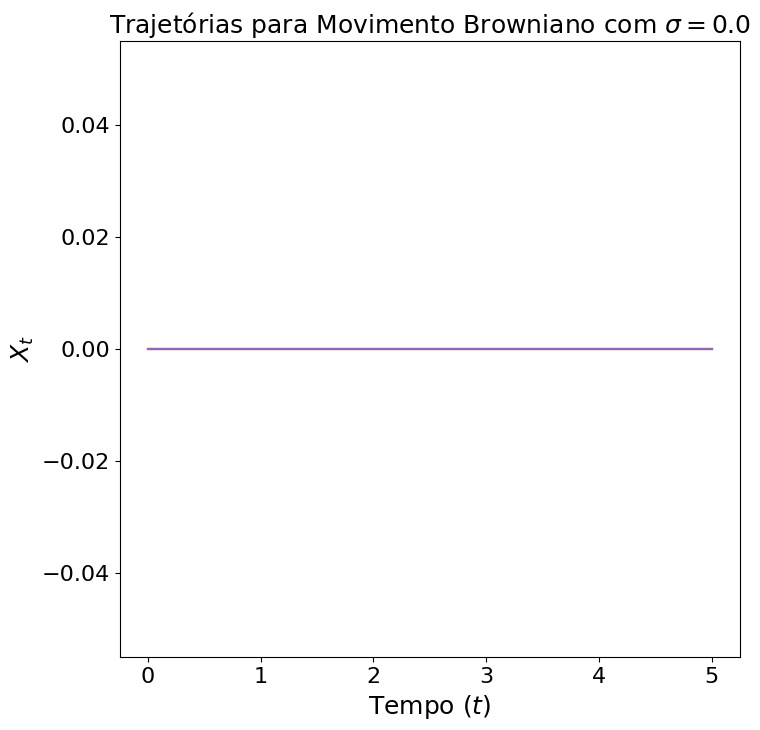

100%|█████████████████████████████████████████████████████████████████████████████| 499/499 [00:00<00:00, 21053.79it/s]


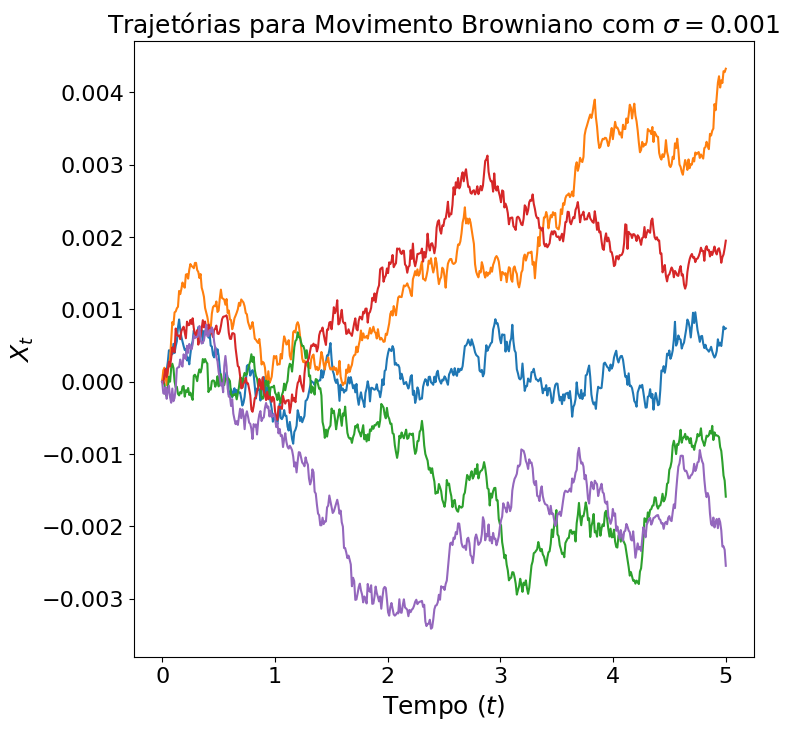

100%|█████████████████████████████████████████████████████████████████████████████| 499/499 [00:00<00:00, 20929.16it/s]


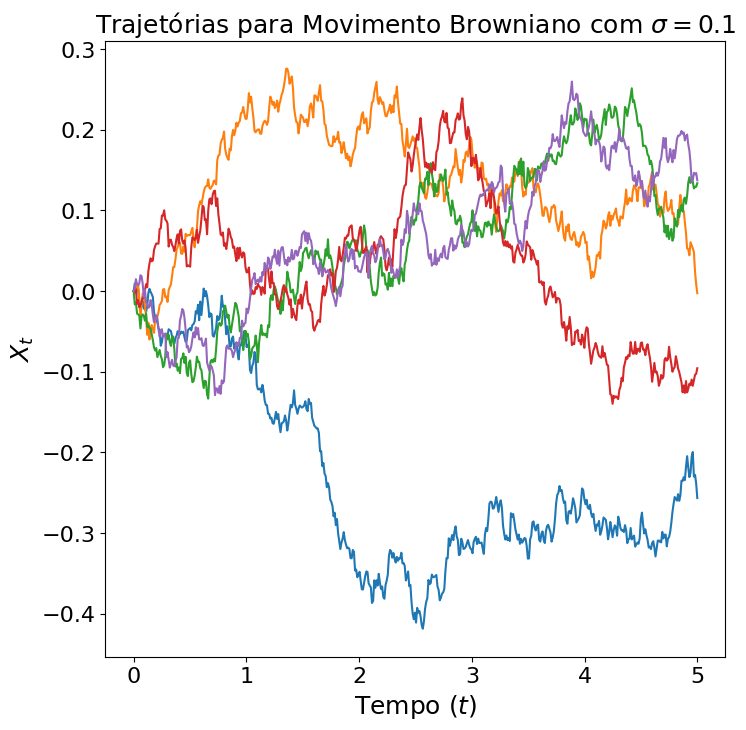

100%|█████████████████████████████████████████████████████████████████████████████| 499/499 [00:00<00:00, 20731.80it/s]


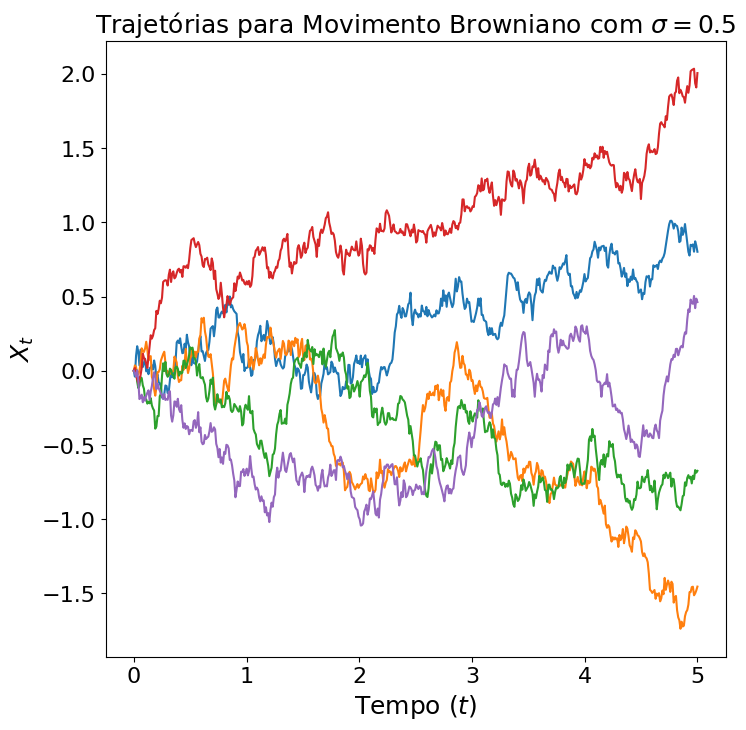

100%|█████████████████████████████████████████████████████████████████████████████| 499/499 [00:00<00:00, 20960.60it/s]


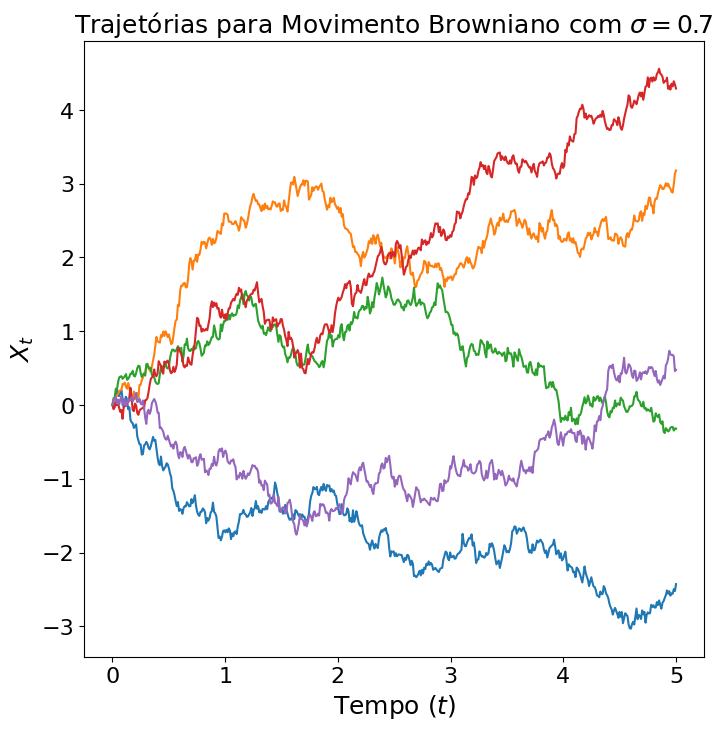

100%|█████████████████████████████████████████████████████████████████████████████| 499/499 [00:00<00:00, 21683.06it/s]


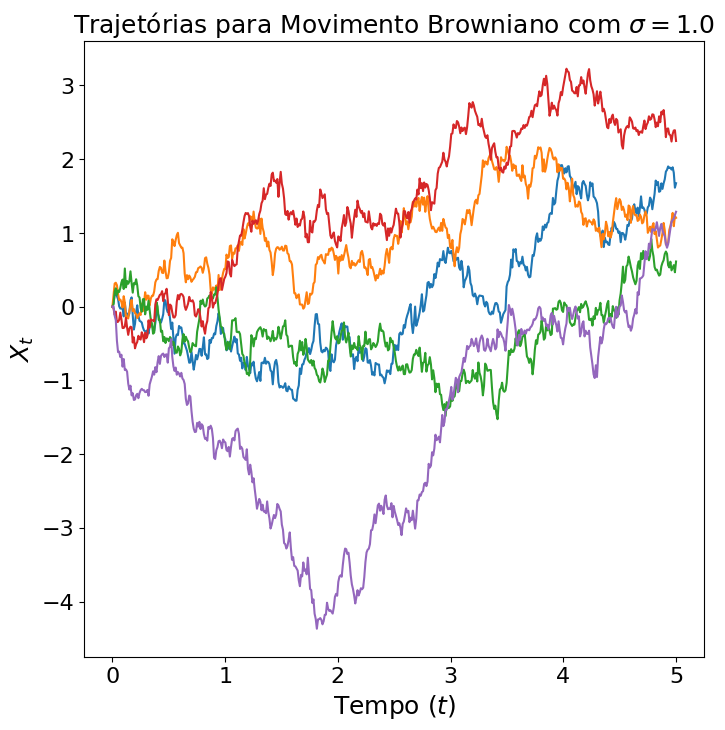

In [7]:
# 7 Simulando o movimento Browniano em 1D
sigma = [0.00, 0.001, 0.1, 0.5, 0.7, 1.0]
for s in sigma:
    brownian_motion = BrownianMotion(s)
    simulator = EulerMaruyamaSimulator(ede=brownian_motion)
    x0 = torch.zeros(5, 1).to(device) # Valores iniciais começando em x0 = 0
    ts = torch.linspace(0.0, 5.0, steps=500) # timesteps para simulação
    
    plt.figure(figsize=(8,8))
    ax = plt.gca()
    ax.set_title(r'Trajetórias para Movimento Browniano com $\sigma=$' + str(s), fontsize=18)
    ax.set_xlabel(r'Tempo ($t$)', fontsize=18)
    plt.xticks(fontsize=16)
    ax.set_ylabel(r'$X_{t}$', fontsize=18)
    plt.yticks(fontsize=16)
    plot_trajectories_1d(x0, simulator, ts, ax)
    plt.show()

In [8]:
# 8 Implementando o método de Ornstein-Uhlenbeck (OU)
class OUMethod(EDE):
    def __init__(self, theta: float, sigma: float):
        self.theta = theta
        self.sigma = sigma

    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Implementação do drift_coefficient para o Método Ou
        Args:
        -xt: estado x no tempo t, shape=(bs, dim)
        -t: tempo t, shape=()
        Retorna:
        drift coefficient: shape=(bs, dim)
        """
        return -self.theta * xt
        
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Implementação do diffusion_coefficient para o Método Ou
        Args:
        -xt: estado x no tempo t, shape=(bs, dim)
        -t: tempo t, shape=()
        Retorna diffusion_coefficient: shape=(bs, dim) 
        """
        return self.sigma * torch.ones_like(xt)

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\rafae\AppData\Local\Temp\ipykernel_19392\1116418285.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'Trajetórias para Método OU com $\sigma = ${sigma}, $\\theta = ${theta}', fontsize=15)
100%|█████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 20665.47it/s]


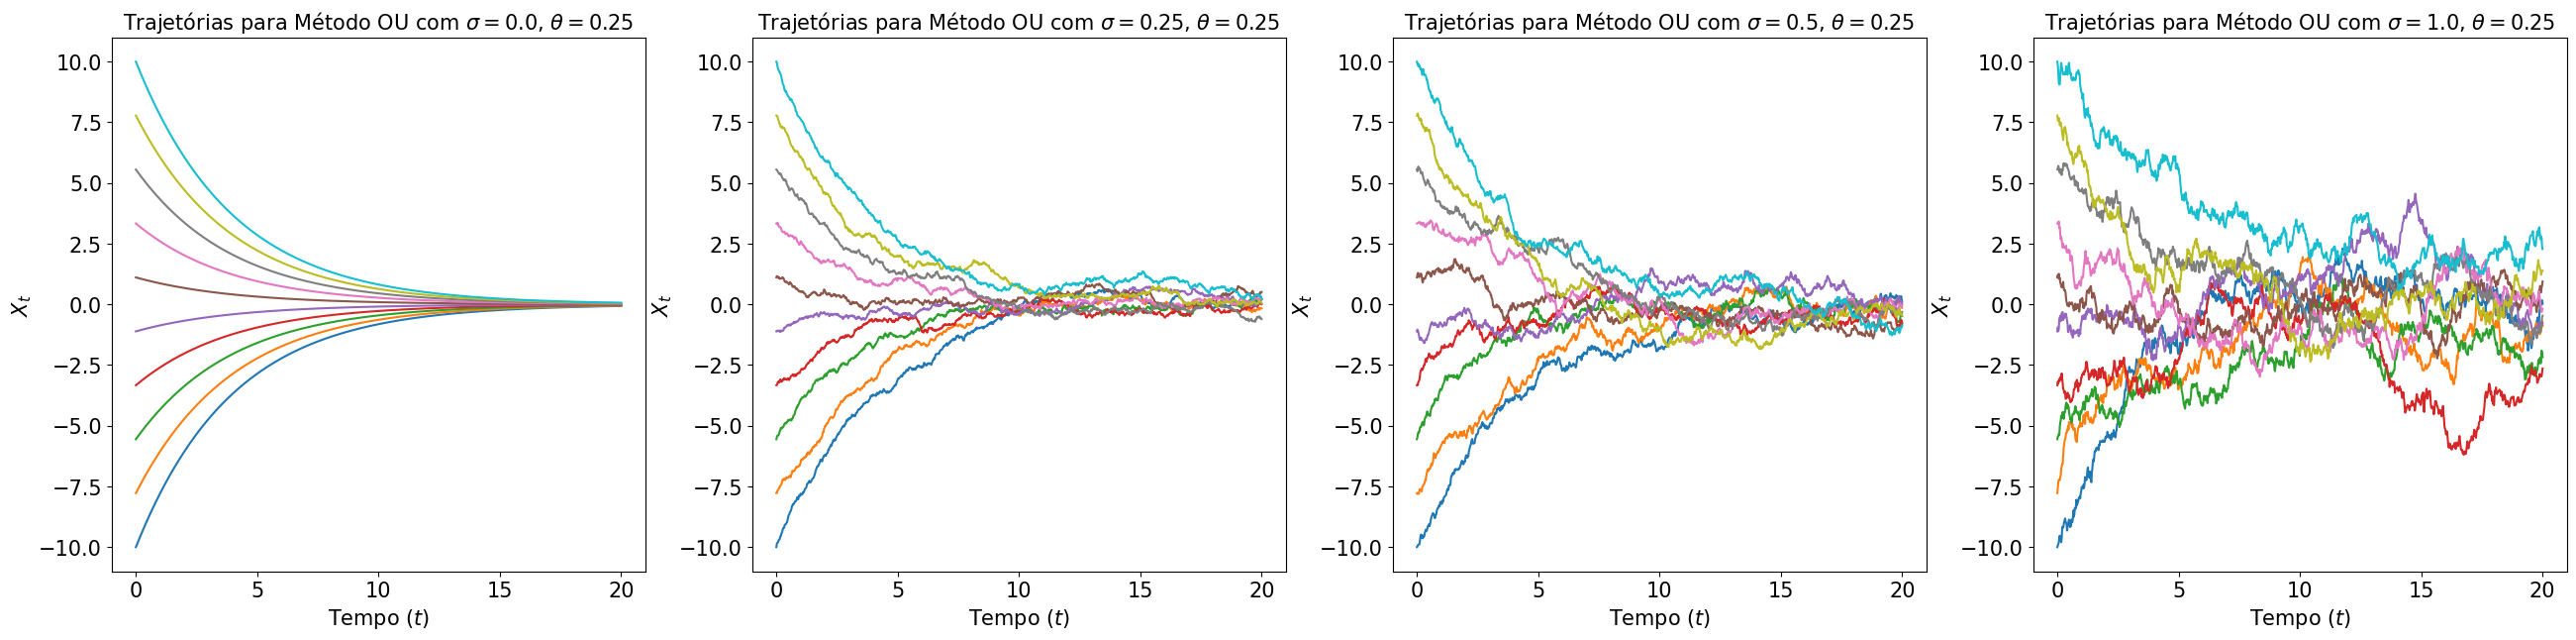

In [9]:
# 9 Teste com do Método OU com múltiplas opções
thetas_and_sigmas = [
    (0.25, 0.0),
    (0.25, 0.25),
    (0.25, 0.5), 
    (0.25, 1.0),
]
simulation_time = 20.0

num_plots = len(thetas_and_sigmas)
fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 7))

for idx, (theta, sigma) in enumerate(thetas_and_sigmas):
    ou_method = OUMethod(theta, sigma)
    simulator = EulerMaruyamaSimulator(ede=ou_method)
    x0 = torch.linspace(-10.0, 10.0, 10).view(-1, 1).to(device) # Valores iniciais comezando em 0
    ts = torch.linspace(0.0, simulation_time, 1000).to(device) # Timesteps para simulação

    ax = axes[idx]
    ax.set_title(f'Trajetórias para Método OU com $\sigma = ${sigma}, $\\theta = ${theta}', fontsize=15)
    ax.set_xlabel(r'Tempo ($t$)', fontsize=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.set_ylabel(r'$X_{t}$', fontsize=15)
    ax.tick_params(axis='y', labelsize=15)
    plot_trajectories_1d(x0, simulator, ts, ax)
plt.show()

In [10]:
# 8 pequena alteração na função plot_trajectories_1d
def plot_scaled_trajectories_1d(x0: torch.Tensor, simulator: Simulator, timesteps: torch.Tensor, time_scale: float, label: str, ax: Optional[Axes] = None):
    """
    Plota as trajetórias para uma EDE unidimensional, dado valores iniciais de x0 e dos timesteps
    Args:
    -x0: estado x no tempo t, shape=(num_trajectories, 1)
    - simulator: Objeto Simulator usado para a simulação
    - t: timesteps durante a simulação, shape=(num_timesteps,)
    - time_scale: fator para escalar o tempo, t
    - label: legenda para gráfico
    -ax: Objeto pyplot Axes para plotar 
    """
    if ax is None:
        ax = plt.gca()
    trajectories = simulator.simulate_with_trajectory(x0, timesteps) # (num_trajectories, num_timesteps,...)
    for trajectory_idx in range(trajectories.shape[0]):
        trajectory = trajectories[trajectory_idx, :, 0] # (num_timesteps,)
        ax.plot(timesteps.cpu() * time_scale, trajectory.cpu(), label=label)

100%|█████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 23933.23it/s]


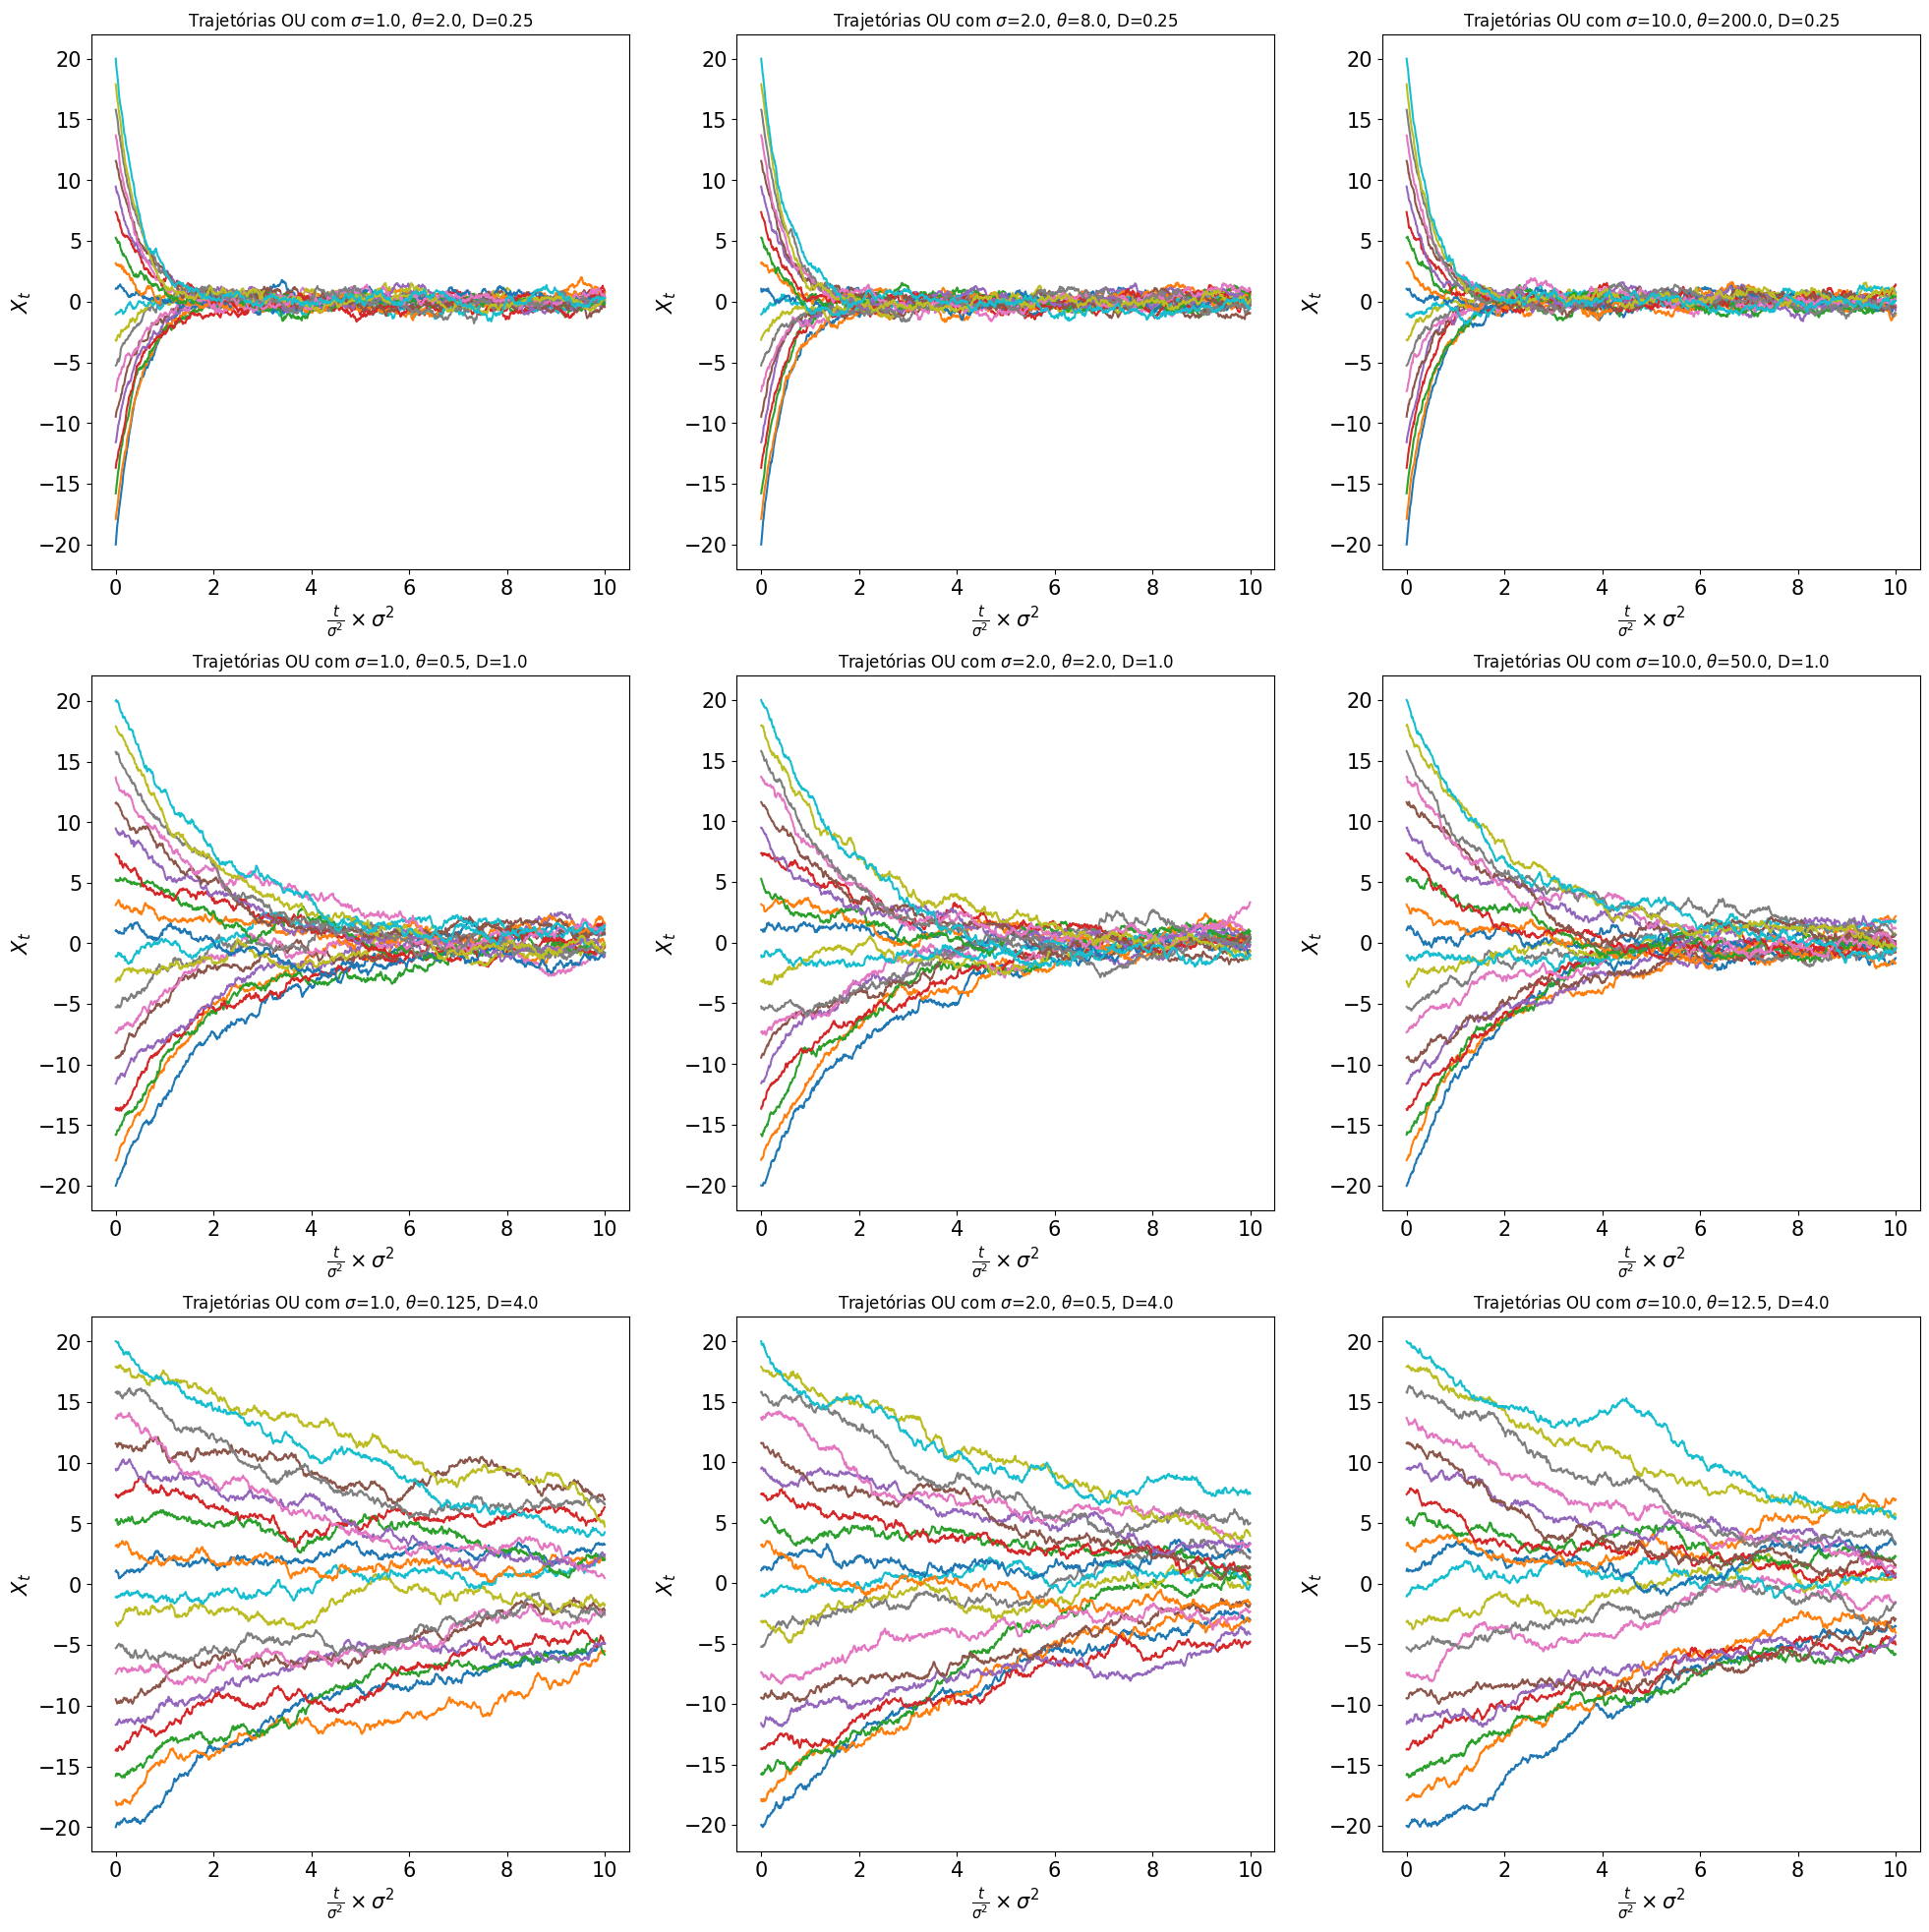

In [11]:
# 10 Reescalando com o tempo
sigmas = [1.0, 2.0, 10.0]
# O coeficiente de difusão efetiva (D) é obtido a partir da variância de Xt ao longo do tempo (regime estacionário)
# Var[Xt] -> \sigma^{2} / 2*\Theta = D, t -> \infty
ds = [0.25, 1.0, 4.0] # Diferentes valores para o coeficiente de difusão efetiva D = \sigma^{2} / 2*\Theta
simulation_time = 10.0

fig, axes = plt.subplots(len(ds), len(sigmas), figsize=(8* len(sigmas), 8 * len(ds)))
axes = axes.reshape((len(ds), len(sigmas))) # 3 x 3
for d_idx, d in enumerate(ds):
    for s_idx, sigma in enumerate(sigmas):
        theta = sigma**2 / (2*d) # Rearranjando a expressão D = \sigma^2 / (2 * \Theta) -> \Theta = \sigma^2 / (2 * \Theta)
        ou_method = OUMethod(theta, sigma)
        simulator = EulerMaruyamaSimulator(ede=ou_method)
        x0 = torch.linspace(-20.0, 20.0, 20).view(-1, 1).to(device)
        time_scale = sigma**2
        ts = torch.linspace(0.0, simulation_time / time_scale, 1000).to(device) # simulation timesteps
        ax = axes[d_idx, s_idx]
        plot_scaled_trajectories_1d(x0=x0, simulator=simulator, timesteps=ts, time_scale=time_scale, label=f'Sigma = {sigma}', ax=ax)
        ax.set_title(fr'Trajetórias OU com $\sigma$={sigma}, $\theta$={theta}, D={d}')
        ax.set_xlabel(r'$\frac{t}{\sigma^2} \times \sigma^2$', fontsize=15)
        ax.set_ylabel('$X_{t}$', fontsize=15)
        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
plt.show()

In [12]:
# 11 Transformando distribuições usando EDEs
# Objetivo xom modelos difusos é N(0, Id) ~ p_data
# Até então foi observado como pontos individuais são transformados por EDEs
# Nessa seção, será explorado como distruições (noisy, ruídos), são transformadas por EDEs (objetivo dos modelos difusos...)
# Esse processo será explorado através de um método chamado Dinâmica Langevin, que computa o score, s(x) = \nabla_x log p(x), ou seja, o gradiente do log da densidade de uma distribuição (p(x))

# 11.1 Construir Classes Density e Sampleable
class Density(ABC):
    @abstractmethod
    def log_density(self, x: torch.Tensor) -> torch.Tensor:
        """
        Retorna o log da densidade em x
        Args:
        - x: shape=(bs, dim)
        Retorna:
        -log_density: shape=(bs, 1)
        """

    # s(x) = \nabla_x log p(x)
    def score(self, x:torch.Tensor):
        """
        Retorna o score, s(x)
        Args:
        -x: shape=(bs, dim)
        Retorna:
        -score: shape=(bs, dim)
        """
        x = x.unsqueeze(1) # prepara para o vmap, adiciona uma dimensão intermediária a x: (bs, dim) -> (bs, 1, dim)
        score = vmap(jacrev(self.log_density))(x) # jacrev = aplica o jacobiano, vmap, aplica a jacobiano a cada elemento do batch. shape=(bs, 1, 1, 1, .....)
        return score.squeeze((1, 2, 3)) # Retorna ao shape original, shape=(bs,...)

class Sampleable(ABC):
    """
    Distribuição que pode ser amostrada
    """
    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Retorna o log da densidade em x
        Args:
        -num_samples: o número desejado de amostras
        -Retorna:
        -samples: shape=(bs, dim)
        """
        pass

In [13]:
# 11.2 Construção de diversas funções de plotagem auxiliares relevantes
def hist2d_sampleable(sampleable: Sampleable, num_samples: int, ax: Optional[Axes] = None, **kwargs):
    if ax is None:
        ax = plt.gca()
    samples = sampleable.sample(num_samples=num_samples) # shape=(ns, 2)
    ax.hist2d(samples[:,0].cpu(), samples[:,1].cpu(), **kwargs)

def scatter_sampleable(sampleable: Sampleable, num_samples: int, ax: Optional[Axes] = None, **kwargs):
    if ax is None:
        ax = plt.gca()
    samples = sampleable.sample(num_samples=num_samples) # shape=(ns,2)
    ax.scatter(samples[:,0].cpu(), samples[:,1].cpu(), **kwargs)

def imshow_density(density: Density, bins: int, scale: float, ax: Optional[Axes] = None, **kwargs):
    if ax is None:
        ax = plt.gca()
    x = torch.linspace(-scale, scale, bins).to(device)
    y = torch.linspace(-scale, scale, bins).to(device)
    X, Y = torch.meshgrid(x, y) # grade 2D
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1) # Vetor 2D plano
    density = density.log_density(xy).reshape(bins, bins).T
    im = ax.imshow(density.cpu(), extent=[-scale, scale, -scale, scale], origin='lower', **kwargs)

def contour_density(density: Density, bins: int, scale: float, ax: Optional[Axes] = None, **kwargs):
    if ax is None:
        ax = plt.gca()
    x = torch.linspace(-scale, scale, bins).to(device)
    y = torch.linspace(-scale, scale, bins).to(device)
    X, Y = torch.meshgrid(x, y) # grade 2D
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1) # Vetor 2D plano
    density = density.log_density(xy).reshape(bins, bins).T
    im = ax.contour(density.cpu(), extent=[-scale, scale, -scale, scale], origin='lower', **kwargs)


In [14]:
# 11.3 Construção de distribuições base Gaussianas
class Gaussian(torch.nn.Module, Sampleable, Density):
    """
    Distribuição gaussiana bi-dimensional. É uma Density e também uma Sampleable. Encapsula (wrapper) torch.distributions.MultivariateNormal
    """
    def __init__(self, mean, cov):
        """
        mean: shape=(2,)
        cov: shape=(2,2)
        """
        super().__init__()
        self.register_buffer('mean', mean)
        self.register_buffer('cov', cov)

    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples: int) -> torch.Tensor:
        return self.distribution.sample((num_samples, ))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)

class GaussianMixture(torch.nn.Module, Sampleable, Density):
    """
    Modelo de distribuição gaussiana mista bi-dimensional. É uma Density e também uma Sampleable. Encapsula (wraper) torch.distributions.MixtureSameFamily
    """
    def __init__(
        self,
        means: torch.Tensor, # nmodes x data_dim
        covs: torch.Tensor, # nmodes x data_dim x data_dim
        weights: torch.Tensor, # nmodes
    ):
        """
        means: shape=(nmodes, 2)
        covs: shape=(nmodes, 2, 2)
        weights: shape=(nmodes, 1)
        """
        super().__init__()
        self.nmodes = means.shape[0]
        self.register_buffer('means', means)
        self.register_buffer('covs', covs)
        self.register_buffer('weights', weights)

    @property
    def dim(self) -> int:
        return self.means.shape[1]

    @property
    def distribution(self):
        return D.MixtureSameFamily(
            mixture_distribution=D.Categorical(probs=self.weights, validate_args=False),
            component_distribution=D.MultivariateNormal(
                loc=self.means,
                covariance_matrix=self.covs,
                validate_args=False,
            ),
            validate_args=False,
        )

    def log_density(self, x: torch.Tensor) -> torch.Tensor:
        return self.distribution.log_prob(x).view(-1, 1)

    def sample(self, num_samples: int) -> torch.Tensor:
        return self.distribution.sample(torch.Size((num_samples,)))

    @classmethod
    def random_2D(
        cls, nmodes: int, std: float,
        scale: float = 10.0, seed = 0.0
    ) -> "GaussianMixture":
        torch.manual_seed(seed),
        means = (torch.rand(nmodes, 2) - 0.5) * scale
        covs = torch.diag_embed(torch.ones(nmodes, 2)) * std**2
        weights = torch.ones(nmodes)
        return cls(means, covs, weights)

    @classmethod
    def symmetric_2D(
        cls, nmodes: int, std: float, scale: float=10.0,
    ) -> "GaussianMixture":
        angles = torch.linspace(0, 2*np.pi, nmodes + 1)[:nmodes]
        means = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1) * scale
        covs = torch.diag_embed(torch.ones(nmodes, 2) * std**2)
        weights = torch.ones(nmodes) / nmodes
        return cls(means, covs, weights)
        

C:\Users\rafae\anaconda3\envs\IA_Gen_env\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


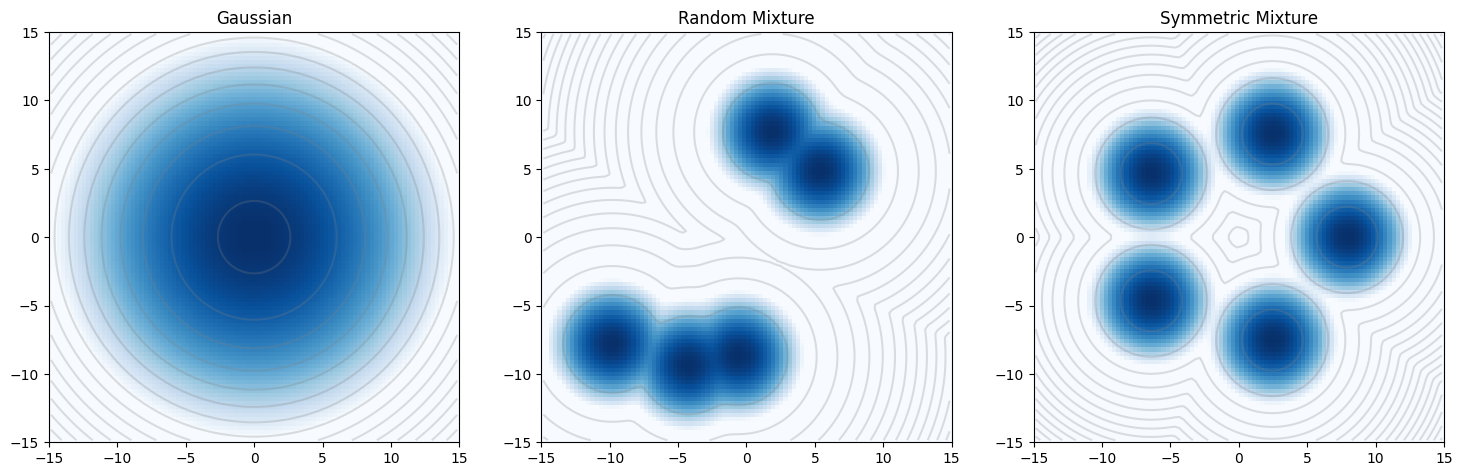

In [15]:
# 11.4 Visualizar densidades
densities = {
    "Gaussian": Gaussian(mean=torch.zeros(2), cov=10 * torch.eye(2)).to(device), # torch.eye = matriz identidade com n dimensões, ex: torch.eye(2) = [1 0], [0 1] -> 2 x 2
    "Random Mixture": GaussianMixture.random_2D(nmodes=5, std=1.0, scale=20.0, seed=3.0).to(device),
    "Symmetric Mixture": GaussianMixture.symmetric_2D(nmodes=5, std=1.0, scale=8.0).to(device),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bins= 100
scale = 15
for idx, (name, density) in enumerate(densities.items()):
    ax = axes[idx]
    ax.set_title(name)
    imshow_density(density, bins, scale, ax, vmin=-15, cmap=plt.get_cmap('Blues'))
    contour_density(density, bins, scale, ax, colors='grey', linestyles='solid', alpha=0.25, levels=20)
plt.show()

In [35]:
# 12 Implementar a dinâmica de Langevin
# dXt = \frac{1}{2}\sigma^{2}\nabla log p(Xt)dt + \sigma Wdt

class LangevinEDE(EDE):
    def __init__(self, sigma: float, density: Density):
        self.sigma = sigma
        self.density = density

    # def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # xt = xt.clone().requires_grad_(True)
        # logp = self.density.log_density(xt) # (bs, )
        # if logp.grad_fn is None:
          #  logp = logp + xt.sum()*0

        # grad = torch.autograd.grad(logp.sum(), xt, create_graph=False)[0] # (bs, dim)
        # return 0.5 * self.sigma**2 * grad.detach() 
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o coeficiente de drift da EDO
        Args:
        - xt: estado x no tempo t, shape=(bs, dim)
        - t: tempo, shape=()
        Retorna:
        - drift: shape=(bs, dim)
        """
        # 1. Garantir que podemos calcular gradientes
        with torch.enable_grad():
            xt = xt.requires_grad_(True)
            logp = self.density.log_density(xt)
            grad = torch.autograd.grad(logp.sum(), xt)[0]
            
        return 0.5 * self.sigma**2 * grad

    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna coeficiente de difusão da EDO
        Args:
        - xt: estado x no tempo t, shape=(bs, dim)
        - t: tempo t, shape=()
        Retorna:
        -coeficiente de difusão, shape=(bs, dim)
        """
        return self.sigma * torch.ones_like(xt)
        
        

In [36]:
# 12.1 Plotando resultados
def every_nth_index(num_timesteps: int, n: int) -> torch.Tensor:
    """
    Computa os indices para gravação na trajetória
    """
    if n == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, n),
            torch.tensor([num_timesteps - 1]),
        ]
    )

def graph_dynamics(
    num_samples: int,
    source_distribution: Sampleable,
    simulator: Simulator,
    density: Density,
    timesteps: torch.Tensor,
    plot_every: int,
    bins: int,
    scale: float
):
    """
    Plota a evolução das ammostras da fonte do tipo de distribuição no equema da simulação determinado pelo objeto simulator (discretização de uma EDO ou EDE)
    Args:
    -num_samples: o número de amostras para simular
    - source_distribution: a distribuição da onde as amostras iniciais são obtidas em t=0
    - simulator: o esquema de distribuição discretizada usado para simular a dinâmica
    -densidade: a densidade alvo
    -timesteps: os timesteps usados pelo simulator
    -plot_every: número de timesteps entre plots consecutivos
    - bins: número de bins para o imshow
    -scale: scale para o imshow
    """
    # Simulação
    x0 = source_distribution.sample(num_samples)
    xts = simulator.simulate_with_trajectory(x0, timesteps)
    indices_to_plot = every_nth_index(len(timesteps), plot_every)
    plot_timesteps = timesteps[indices_to_plot]
    plot_xts = xts[:, indices_to_plot]

    # Graph
    fig, axes = plt.subplots(2, len(plot_timesteps), figsize=(8 * len(plot_timesteps), 16))
    axes = axes.reshape((2, len(plot_timesteps)))
    for t_idx in range(len(plot_timesteps)):
        t = plot_timesteps[t_idx].item()
        xt = plot_xts[:, t_idx]
        # Scatter axes
        scatter_ax = axes[0, t_idx]
        imshow_density(density, bins, scale, scatter_ax, vmin=-15, alpha=0.25, cmap=plt.get_cmap('Blues'))
        scatter_ax.scatter(xt[:,0].cpu(), xt[:, 1].cpu(), marker='x', color='black', alpha=0.75, s=15)
        scatter_ax.set_title(f'Amostras em t={t:.1f}', fontsize=20)
        scatter_ax.set_xticks([])
        scatter_ax.set_yticks([])

        # Kdeplot axes
        kdeplot_ax = axes[1, t_idx]
        imshow_density(density, bins, scale, kdeplot_ax, vmin=-15, alpha=0.5, cmap=plt.get_cmap('Blues'))
        sns.kdeplot(x=xt[:,0].cpu(), y=xt[:, 1].cpu(), alpha=0.5, ax=kdeplot_ax, color='grey')
        kdeplot_ax.set_xticks([])
        kdeplot_ax.set_yticks([])
        kdeplot_ax.set_xlabel("")
        kdeplot_ax.set_ylabel("")

    plt.show()

100%|███████████████████████████████████████████████████████████████████████████████| 999/999 [00:01<00:00, 689.01it/s]


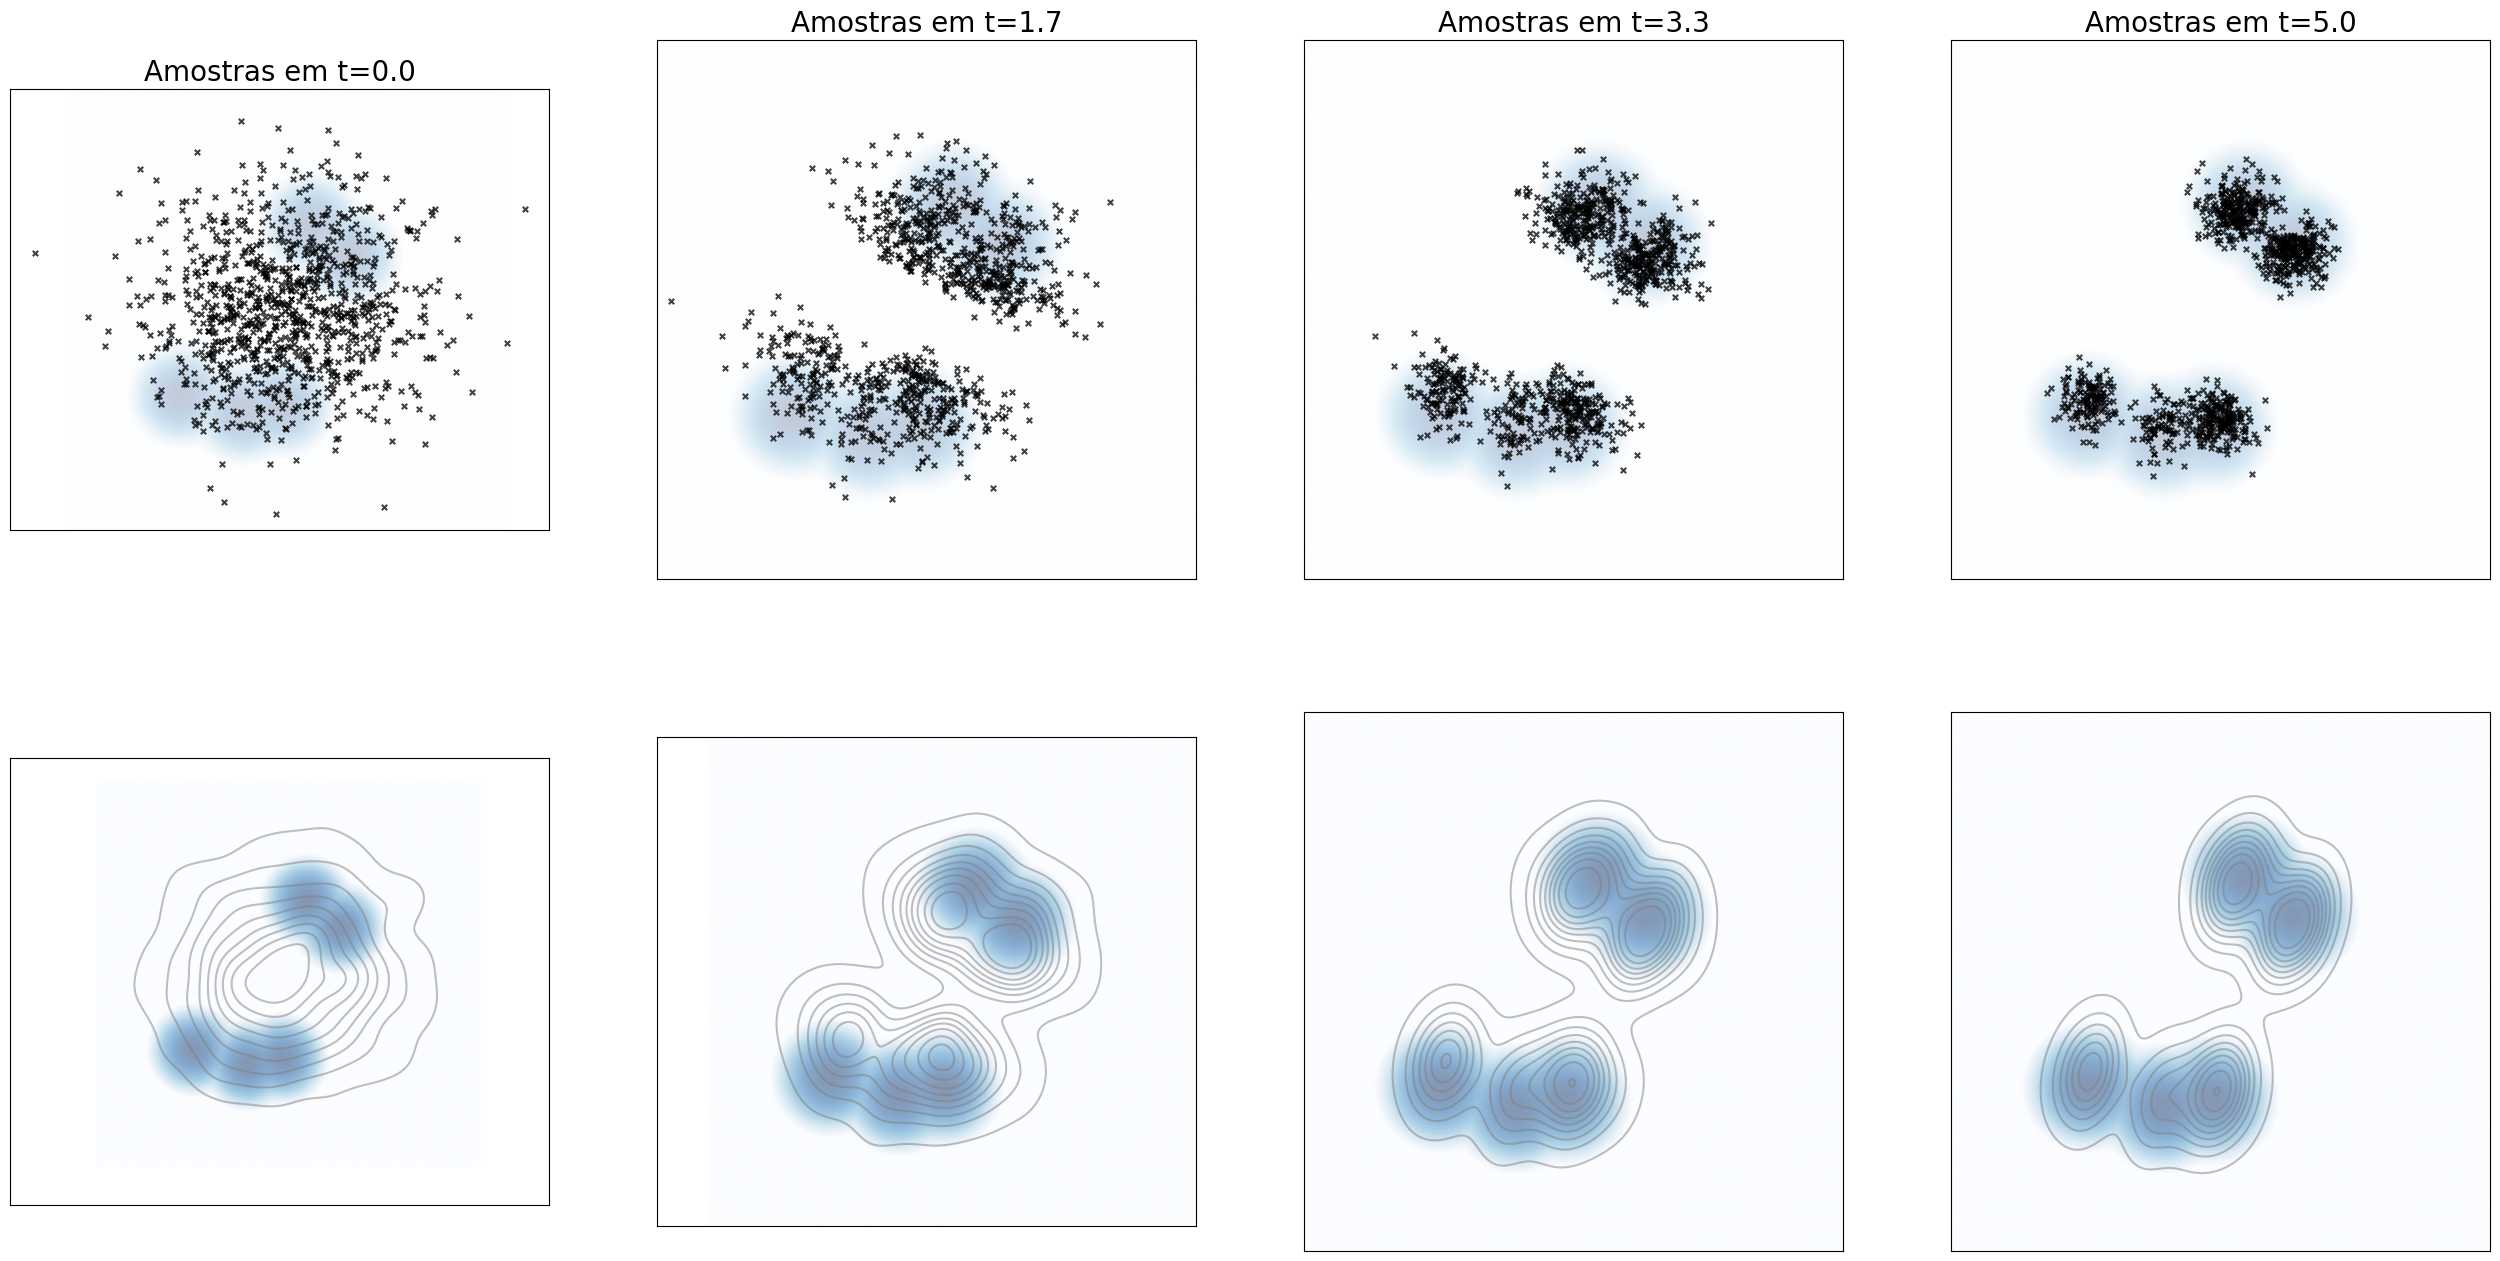

In [37]:
# Construindo simulador
target = GaussianMixture.random_2D(nmodes=5, std=0.75, scale=15.0, seed=3.0).to(device)
ede = LangevinEDE(sigma=0.6, density=target)
simulator = EulerMaruyamaSimulator(ede)

# Plotando resultados!
graph_dynamics(
    num_samples=1000,
    source_distribution=Gaussian(mean=torch.zeros(2), cov=20 * torch.eye(2).to(device)),
    simulator=simulator,
    density=target,
    timesteps=torch.linspace(0,5.0,1000).to(device),
    plot_every=334,
    bins=200,
    scale=15
)